In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import optuna
import time
import math
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, average_precision_score, PrecisionRecallDisplay, average_precision_score, precision_recall_curve, precision_score, recall_score, f1_score

In [2]:
df = pd.read_csv('creditcard.csv')

# Zapoznanie ze zbiorem danych

In [3]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
df.shape

(284807, 31)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [8]:
df.columns.tolist()

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount',
 'Class']

In [9]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [10]:
creditcard_normal_or_fraud = df['Class'].value_counts()
print(f'Ilość transakcji wynosi: {df.shape[0]}, z czego {((creditcard_normal_or_fraud[0]/df.shape[0])*100):.2f}% ({df['Class'].value_counts()[0]}) to uczciwe transakcje, zaś {((creditcard_normal_or_fraud[1]/df.shape[0])*100):.2f}% ({df['Class'].value_counts()[1]}) to oszustwa finansowe (creditcard fraud).')

Ilość transakcji wynosi: 284807, z czego 99.83% (284315) to uczciwe transakcje, zaś 0.17% (492) to oszustwa finansowe (creditcard fraud).


# Podział zbioru danych na dane treningowe i testowe oraz skalowanie danych

In [11]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# LightGBM

## LightGBM jest to algorytm oparty na drzewach decyzyjnych. Podobnie jak XGBoost, LightGBM oblicza wagi (residua - błędy), które uczą się przewidywać błędy poprzedniego drzewa. LightGBM różni się od XGBoost tym, że XGBoost tworzy rozgałęzienia dla każdego węzła, np. początek drzewa to 1 węzeł, drugi poziom to 2 węzły, trzeci to 4 węzły, czwarty to 8 węzłów itd. (2^n), zaś LightGBM najpierw rozgałęzia się na dwa węzły, a następnie w każdym kolejnym kroku algorytm wybiera najbardziej obiecujący liść i rozgałęzia go na 2 węzły. Dzięki temu LightGBM działa znacznie szybciej niż XGBoost, dzięki mniejszej ilości liści w drzewie.

In [12]:
# https://www.kaggle.com/code/prashant111/lightgbm-classifier-in-python
model_lgbm = lgb.LGBMClassifier(random_state=42, verbose=-1)
model_lgbm.fit(X_train, y_train)

,random_state,42
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


In [13]:
y_pred_lgbm = model_lgbm.predict(X_test)
y_pred_proba_lgbm = model_lgbm.predict_proba(X_test)[:, 1]

print('Przed użyciem SMOTE.')
print('Dokładność (Accuracy Score):', accuracy_score(y_test, y_pred_lgbm))
print('Precision-Recall AUC:', average_precision_score(y_test, y_pred_proba_lgbm))
print('Macierz pomyłek (Confusion Matrix):\n', confusion_matrix(y_test, y_pred_lgbm))
print('Raport\n', classification_report(y_test, y_pred_lgbm))

Przed użyciem SMOTE.
Dokładność (Accuracy Score): 0.9978757768336786
Precision-Recall AUC: 0.20278343310260627
Macierz pomyłek (Confusion Matrix):
 [[56795    69]
 [   52    46]]
Raport
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.40      0.47      0.43        98

    accuracy                           1.00     56962
   macro avg       0.70      0.73      0.72     56962
weighted avg       1.00      1.00      1.00     56962



# SMOTE

## SMOTE pozwala na stworzenie dodatkowych danych (syntetycznych), jeśli danych w jednej klasie jest znacznie mniej niż w drugiej. Tworzenie dodatkowych danych działa na zasadzie KNN, czyli tworzy realistyczne punkty w obszarze, którym występują punkty danej klasy (fraudy).

In [14]:
# https://www.geeksforgeeks.org/machine-learning/smote-for-imbalanced-classification-with-python/
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

## Na wykresie można zauważyć ilość danych przed i po użyciu SMOTE. Na pierwszym wykresie dla drugiej klasy (fraud) jest znacznie mniej próbek niż dla pierwszej (non-fraud). Drugi wykres pokazuje taką samą ilość danych dla obu klas po utworzeniu danych syntetycznych dla drugiej klasy (fraud).

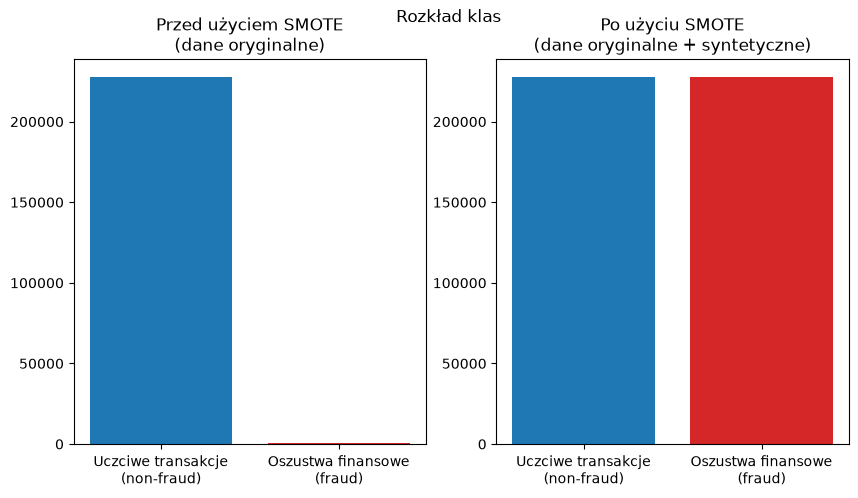

In [15]:
# https://matplotlib.org/stable/release/prev_whats_new/dflt_style_changes.html
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Rozkład klas')

ax[0].bar(y_train.value_counts().index, y_train.value_counts().values, color=['#1f77b4', '#d62728'])
ax[0].set_title('Przed użyciem SMOTE\n(dane oryginalne)')
ax[0].set_xticks([0, 1], ['Uczciwe transakcje\n(non-fraud)', 'Oszustwa finansowe\n(fraud)'])

ax[1].bar(y_train_smote.value_counts().index, y_train_smote.value_counts().values, color=['#1f77b4', '#d62728'])
ax[1].set_title('Po użyciu SMOTE\n(dane oryginalne + syntetyczne)')
ax[1].set_xticks([0, 1], ['Uczciwe transakcje\n(non-fraud)', 'Oszustwa finansowe\n(fraud)'])

plt.show()

In [16]:
model_lgbm_smote = lgb.LGBMClassifier(random_state=42, verbose=-1)
model_lgbm_smote.fit(X_train_smote, y_train_smote)

,random_state,42
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


In [17]:
y_pred_lgbm_smote = model_lgbm_smote.predict(X_test)
y_pred_proba_lgbm_smote = model_lgbm_smote.predict_proba(X_test)[:, 1]

print('Po użyciu SMOTE.')
print('Dokładność (Accuracy Score):', accuracy_score(y_test, y_pred_lgbm_smote))
print('Precision-Recall AUC:', average_precision_score(y_test, y_pred_proba_lgbm_smote))
print('Macierz pomyłek (Confusion Matrix):\n', confusion_matrix(y_test, y_pred_lgbm_smote))
print('Raport\n', classification_report(y_test, y_pred_lgbm_smote))

Po użyciu SMOTE.
Dokładność (Accuracy Score): 0.998735999438222
Precision-Recall AUC: 0.7440001757529559
Macierz pomyłek (Confusion Matrix):
 [[56811    53]
 [   19    79]]
Raport
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.60      0.81      0.69        98

    accuracy                           1.00     56962
   macro avg       0.80      0.90      0.84     56962
weighted avg       1.00      1.00      1.00     56962



In [18]:
model_lgbm_smote.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'num_leaves': 31,
 'objective': None,
 'random_state': 42,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0,
 'verbose': -1}

# Optuna

## Optuna to biblioteka w Pythonie służąca do dostrajania hiperparametrów. Optuna nie sprawdza wszystkich kombinacji jak GridSearchCV, ale na początku zaczyna od losowych zakresów, a potem sprawdza te najbardziej obiecujące. Dzięki temu, że Optuna wykonuje tylko jeden trening na danych oraz nie sprawdza słabych kombinacji to działa znacznie szybciej niż GridSearchCV.

### Znaczenie parametrów:
### 1. 'n_estimators': ilość drzew jaką model zbuduje zanim przestanie.
### 2. 'num_leaves': ile liści może posiadać każde drzewo (na jego końcu).
### 3. 'max_depth': jak bardzo może być rozgałęzione jedno drzewo (ile poziomów).
### 4. 'learning_rate': tempo uczenia, czyli jak duża poprawka zostanie wprowadzona w każdym kolejnym drzewie.
### 5. 'min_child_samples': minimalna ilość próbek w danym liściu. Liście z mniejszą ilością próbek nie są tworzone.

In [19]:
# https://www.kaggle.com/code/durgeshtiwari0153/optuna-tutorial
def objective_A(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50)
    }

    model = lgb.LGBMClassifier(**params, random_state=42, verbose=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return accuracy_score(y_test, y_pred)

In [20]:
execution_time = dict()

In [21]:
start_time = time.time()
study_A = optuna.create_study(direction='maximize')
study_A.optimize(objective_A, n_trials=50)
end_time = time.time()
execution_time['Optuna A'] = end_time - start_time

[I 2026-08-02 21:27:46,630] A new study created in memory with name: no-name-57391a8e-43d7-4d9d-b0fe-6a30c8f9f808
[I 2026-08-02 21:27:50,338] Trial 0 finished with value: 0.9979811102138267 and parameters: {'n_estimators': 226, 'num_leaves': 58, 'max_depth': 4, 'learning_rate': 0.06305872736945348, 'min_child_samples': 14}. Best is trial 0 with value: 0.9979811102138267.
[I 2026-08-02 21:27:55,465] Trial 1 finished with value: 0.9970682209192093 and parameters: {'n_estimators': 284, 'num_leaves': 35, 'max_depth': 9, 'learning_rate': 0.1792672058141676, 'min_child_samples': 45}. Best is trial 0 with value: 0.9979811102138267.
[I 2026-08-02 21:27:58,222] Trial 2 finished with value: 0.9992275552122467 and parameters: {'n_estimators': 139, 'num_leaves': 103, 'max_depth': 4, 'learning_rate': 0.03544032704631272, 'min_child_samples': 35}. Best is trial 2 with value: 0.9992275552122467.
[I 2026-08-02 21:28:01,340] Trial 3 finished with value: 0.9994382219725431 and parameters: {'n_estimators

In [22]:
best_trial_A = study_A.best_trial
print('Najlepszy wynik (trial): ', best_trial_A.value)
print('Najlepsze parametry: ', best_trial_A.params)

Najlepszy wynik (trial):  0.9995962220427653
Najlepsze parametry:  {'n_estimators': 160, 'num_leaves': 29, 'max_depth': 11, 'learning_rate': 0.030555265535896152, 'min_child_samples': 39}


In [23]:
def objective_B(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50)
    }

    model = lgb.LGBMClassifier(**params, random_state=42, verbose=-1)
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    return average_precision_score(y_test, y_pred_proba)

In [24]:
start_time = time.time()
study_B = optuna.create_study(direction='maximize')
study_B.optimize(objective_B, n_trials=50)
end_time = time.time()
execution_time['Optuna B'] = end_time - start_time

[I 2026-08-02 21:31:44,304] A new study created in memory with name: no-name-7219ce82-b0b1-4e37-ab88-9af550e5ba91
[I 2026-08-02 21:31:46,203] Trial 0 finished with value: 0.4502759161633421 and parameters: {'n_estimators': 57, 'num_leaves': 117, 'max_depth': 8, 'learning_rate': 0.06877707467846295, 'min_child_samples': 32}. Best is trial 0 with value: 0.4502759161633421.
[I 2026-08-02 21:31:51,175] Trial 1 finished with value: 0.008582187253198243 and parameters: {'n_estimators': 246, 'num_leaves': 65, 'max_depth': 9, 'learning_rate': 0.12483569895949514, 'min_child_samples': 22}. Best is trial 0 with value: 0.4502759161633421.
[I 2026-08-02 21:31:58,631] Trial 2 finished with value: 0.8650273392026155 and parameters: {'n_estimators': 244, 'num_leaves': 127, 'max_depth': 11, 'learning_rate': 0.03446840201672958, 'min_child_samples': 26}. Best is trial 2 with value: 0.8650273392026155.
[I 2026-08-02 21:32:01,949] Trial 3 finished with value: 0.07142003327358548 and parameters: {'n_estim

In [25]:
best_trial_B = study_B.best_trial
print('Najlepszy wynik (trial): ', best_trial_B.value)
print('Najlepsze parametry: ', best_trial_B.params)

Najlepszy wynik (trial):  0.8836556715948006
Najlepsze parametry:  {'n_estimators': 299, 'num_leaves': 69, 'max_depth': 10, 'learning_rate': 0.025541913362857036, 'min_child_samples': 41}


In [26]:
best_params_A = best_trial_A.params

model_lgbm_smote_A = lgb.LGBMClassifier(**best_params_A, random_state=42, verbose=-1)
model_lgbm_smote_A.fit(X_train_smote, y_train_smote)

,num_leaves,29
,max_depth,11
,learning_rate,0.030555265535896152
,n_estimators,160
,min_child_samples,39
,random_state,42
,verbose,-1
,boosting_type,'gbdt'
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [27]:
y_pred_A = model_lgbm_smote_A.predict(X_test)
y_pred_proba_A = model_lgbm_smote_A.predict_proba(X_test)[:, 1]

print('Dokładność (Accuracy Score):', accuracy_score(y_test, y_pred_A))
print('Precision-Recall AUC:', average_precision_score(y_test, y_pred_proba_A))
print('Macierz pomyłek (Confusion Matrix):\n', confusion_matrix(y_test, y_pred_A))
print('Raport\n', classification_report(y_test, y_pred_A))

Dokładność (Accuracy Score): 0.996278220568098
Precision-Recall AUC: 0.7390043813610254
Macierz pomyłek (Confusion Matrix):
 [[56662   202]
 [   10    88]]
Raport
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.30      0.90      0.45        98

    accuracy                           1.00     56962
   macro avg       0.65      0.95      0.73     56962
weighted avg       1.00      1.00      1.00     56962



In [28]:
best_params_B = best_trial_B.params

model_lgbm_smote_B = lgb.LGBMClassifier(**best_params_B, random_state=42, verbose=-1)
model_lgbm_smote_B.fit(X_train_smote, y_train_smote)

,num_leaves,69
,max_depth,10
,learning_rate,0.025541913362857036
,n_estimators,299
,min_child_samples,41
,random_state,42
,verbose,-1
,boosting_type,'gbdt'
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [29]:
y_pred_B = model_lgbm_smote_B.predict(X_test)
y_pred_proba_B = model_lgbm_smote_B.predict_proba(X_test)[:, 1]

print('Dokładność (Accuracy Score):', accuracy_score(y_test, y_pred_B))
print('Precision-Recall AUC:', average_precision_score(y_test, y_pred_proba_B))
print('Macierz pomyłek (Confusion Matrix):\n', confusion_matrix(y_test, y_pred_B))
print('Raport\n', classification_report(y_test, y_pred_B))

Dokładność (Accuracy Score): 0.9989466661985184
Precision-Recall AUC: 0.8642177464339991
Macierz pomyłek (Confusion Matrix):
 [[56814    50]
 [   10    88]]
Raport
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.64      0.90      0.75        98

    accuracy                           1.00     56962
   macro avg       0.82      0.95      0.87     56962
weighted avg       1.00      1.00      1.00     56962



# GridSearchCV

## GridSearchCV sprawdza wszystkie podane hiperparametry na domyślnym ustawieniu 3-fold (3 treningi na trzy różne podziały danych) i jako wynik podaje najlepsze obliczone przez siebie hiperparametry dla modelu. GridSearchCV trwa znacznie dłużej, bo ilość kombinacji w tym wypadku wynosi 2^5 * 3 = 96 (każdy parametr ma 2 wartości oraz domyślne ustawienie to 3-fold) niż Optuna.

In [30]:
param_grid = {
    'n_estimators': [100, 300],
    'num_leaves': [31, 127],
    'max_depth': [5, 12],
    'learning_rate': [0.01, 0.2],
    'min_child_samples': [10, 50]
}

In [31]:
start_time = time.time()
grid_search = GridSearchCV(estimator=model_lgbm_smote, param_grid=param_grid, scoring='accuracy')
grid_search.fit(X_train_smote, y_train_smote)
end_time = time.time()
execution_time['GridSearchCV'] = end_time - start_time

In [32]:
print('Najlepsze parametry (GridSearchCV): ', grid_search.best_params_)
print('Najlepszy wynik cross-validation: ', grid_search.best_score_)

Najlepsze parametry (GridSearchCV):  {'learning_rate': 0.2, 'max_depth': 12, 'min_child_samples': 50, 'n_estimators': 300, 'num_leaves': 127}
Najlepszy wynik cross-validation:  0.9999010775464077


In [33]:
y_pred_grid_search_cv = grid_search.predict(X_test)
y_pred_proba_grid_search_cv = grid_search.predict_proba(X_test)[:, 1]

print('Dokładność (Accuracy Score):', accuracy_score(y_test, y_pred_grid_search_cv))
print('Precision-Recall AUC:', average_precision_score(y_test, y_pred_proba_grid_search_cv))
print('Macierz pomyłek (Confusion Matrix):\n', confusion_matrix(y_test, y_pred_grid_search_cv))
print('Raport\n', classification_report(y_test, y_pred_grid_search_cv))

Dokładność (Accuracy Score): 0.9994557775359011
Precision-Recall AUC: 0.8831085834963802
Macierz pomyłek (Confusion Matrix):
 [[56848    16]
 [   15    83]]
Raport
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.85      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



# Jak widać poniżej, czas poszukiwania najlepszych hiperparametrów przez Optune jest znacznie szybszy niż przez GridSearchCV.

In [34]:
# https://stackoverflow.com/questions/62198128/python-elapsed-time-as-days-hours-minutes-seconds
for key, value in execution_time.items():
    print(f'Czas trwania poszukiwania najlepszych hiperparametrów dla {key} wynosi: {time.strftime('%M minut %S sekund', time.gmtime(value))}.')

Czas trwania poszukiwania najlepszych hiperparametrów dla Optuna A wynosi: 03 minut 57 sekund.
Czas trwania poszukiwania najlepszych hiperparametrów dla Optuna B wynosi: 05 minut 02 sekund.
Czas trwania poszukiwania najlepszych hiperparametrów dla GridSearchCV wynosi: 23 minut 46 sekund.


# Threshold tuning

## Threshold to ustalona wartość graniczna, z użyciem której model decyduje do której klasy należy dana próbka. Domyślnie wartość threshold ustawiona jest na 0.5 (50%) i po jej przekroczeniu dana klasa jest przyznawana danej próbce. W niektórych przypadkach, gdy Recall jest zbyt niski, bo model nie łapie przypadków z drugiej klasy mimo potencjalej dużej dokładności, threshold może naprawić ten problem. Jeśli ważniejsze jest wykrycie danej klasy nawet kosztem dokładności (nadinterpretacji) to warto zmodyfikować próg (threshold).

In [35]:
# https://www.geeksforgeeks.org/machine-learning/how-to-use-scikit-learns-tunedthresholdclassifiercv-for-threshold-optimization/
y_pred_proba_all_models = {
    'LightGBM': model_lgbm.predict_proba(X_test)[:, 1],
    'LightGBM + SMOTE': model_lgbm_smote.predict_proba(X_test)[:, 1],
    'Optuna A': model_lgbm_smote_A.predict_proba(X_test)[:, 1],
    'Optuna B': model_lgbm_smote_B.predict_proba(X_test)[:, 1],
    'GridSearchCV': grid_search.predict_proba(X_test)[:, 1]
}

results_threshold_best = {}
y_pred_best_threshold_all_models = {}

for key, y_pred_proba in y_pred_proba_all_models.items():
    print(f'Dla modelu: {key}.')
    print('ROC AUC dla domyślnego threshold: ', roc_auc_score(y_test, y_pred_proba))
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
    fscore = (2 * precision * recall) / (precision + recall)
    best_threshold = thresholds[np.argmax(fscore)]
    print(f'Najlepszy threshold: {best_threshold}; precision: {precision[np.argmax(fscore)]}; recall: {recall[np.argmax(fscore)]}; F1-score: {fscore[np.argmax(fscore)]}')
    y_pred_best_threshold = (y_pred_proba >= best_threshold).astype(int)
    roc_auc_best_threshold = roc_auc_score(y_test, y_pred_best_threshold)
    print('ROC AUC dla najlepszego threshold: ', roc_auc_best_threshold)
    print('Raport:\n', classification_report(y_test, y_pred_best_threshold))

    results_threshold_best[key] = {
        'fscore': fscore[np.argmax(fscore)],
        'precision': precision[np.argmax(fscore)],
        'recall': recall[np.argmax(fscore)],
        'threshold': best_threshold
    }

    y_pred_best_threshold_all_models[key] = y_pred_best_threshold

Dla modelu: LightGBM.
ROC AUC dla domyślnego threshold:  0.7063384494906573
Najlepszy threshold: 1.0; precision: 0.42990654205607476; recall: 0.46938775510204084; F1-score: 0.44878048780487806
ROC AUC dla najlepszego threshold:  0.7341575100777509
Raport:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.43      0.47      0.45        98

    accuracy                           1.00     56962
   macro avg       0.71      0.73      0.72     56962
weighted avg       1.00      1.00      1.00     56962

Dla modelu: LightGBM + SMOTE.
ROC AUC dla domyślnego threshold:  0.9134207970610867
Najlepszy threshold: 0.9441636186270368; precision: 0.8953488372093024; recall: 0.7857142857142857; F1-score: 0.8369565217391304
ROC AUC dla najlepszego threshold:  0.8927780066725619
Raport:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0

## Accuracy pokazuje w jakim procencie przypadków model podjął właściwą decyzję w klasyfikacji. W niektórych przypadkach Accuracy może być niewystarczające, aby właściwie ocenić dany model. Jeśli ilość próbek dla jednej klasy mocno przeważa to model może dać wysokie Accuracy nawet w przypadkach, gdy model ocenia wszystkie próbki jako jedną klasę.
## Precision (TP/(TP+FP)): spośród wszystkich przypadków (transakcji), które model uznał za daną klasę (fraudy), Precision mówi jaki procent stanowi faktycznie ta klasa (fraudy).
## Recall (TP/(TP+FN)): jaki procent przypadków model rozpoznał jako dana klasa sposród wszystkich przypadków dla tej klasy.
## F-1 score (2*(Precision*Recall)/(Precision+Recall)): średnia harmoniczna Precision i Recall. Jest to metryka, która pozwala łatwiej ocenić połączenie metryki Precision oraz Recall jednocześnie. Jeśli obie te metryki są równie ważne to F1-score potrafi ocenić jak dobry jest model w skrajnych przypadkach.
## ROC AUC: pole pod krzywą ROC. Krzywa łączy punkty (FPR: FP/(FP+TN) oraz TPR: Recall) dla wszystkich możliwych progów decyzyjnych. Mówi jak dobrze model rozdziela wszystkie dane (transakcje) na dane klasy (normalne i fraudy).
## Precision-Recall AUC: pole pod krzywą Precision-Recall. Krzywa łączy punkty (Precision oraz Recall) dla wszystkich możliwych progów decyzyjnych. Mówi, które spośród danych (transakcji), które wskazał model jako daną klasę (fraudy) - ile to naprawdę fraudy oraz ile prawdziwych fraudów udało się rozpoznać.

In [36]:
# https://www.geeksforgeeks.org/pandas/how-to-create-an-empty-dataframe-and-append-rows-columns-to-it-in-pandas/
metrics_all_models = pd.DataFrame()

y_pred_all_models = {
    'LightGBM': model_lgbm.predict(X_test),
    'LightGBM + SMOTE': model_lgbm_smote.predict(X_test),
    'Optuna A': model_lgbm_smote_A.predict(X_test),
    'Optuna B': model_lgbm_smote_B.predict(X_test),
    'GridSearchCV': grid_search.predict(X_test)
}

for model_name in ['LightGBM', 'LightGBM + SMOTE', 'Optuna A', 'Optuna B', 'GridSearchCV']:
    model_metrics_values = pd.DataFrame([{
        'Model name': model_name,
        'Precision (non-fraud)': np.around(precision_score(y_test, y_pred_all_models[model_name], average=None), 2).tolist()[0],
        'Precision (fraud)': np.around(precision_score(y_test, y_pred_all_models[model_name], average=None), 2).tolist()[1],
        'Recall (non-fraud)': np.around(recall_score(y_test, y_pred_all_models[model_name], average=None), 2).tolist()[0],
        'Recall (fraud)': np.around(recall_score(y_test, y_pred_all_models[model_name], average=None), 2).tolist()[1],
        'F1 (non-frauud)': np.around(f1_score(y_test, y_pred_all_models[model_name], average=None), 2).tolist()[0],
        'F1 (fraud)': np.around(f1_score(y_test, y_pred_all_models[model_name], average=None), 2).tolist()[1],
        'ROC AUC': round(roc_auc_score(y_test, y_pred_best_threshold), 2),
        'Precision-Recall AUC': round(average_precision_score(y_test, y_pred_all_models[model_name]), 2)
    }])

    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_all_models[model_name])
    fscore = (2 * precision * recall) / (precision + recall)
    best_threshold = thresholds[np.argmax(fscore)]
    y_pred_best_threshold = (y_pred_proba_all_models[model_name] >= best_threshold).astype(int)
    
    model_metrics_values_best_threshold = pd.DataFrame([{
        'Model name': model_name+str(' (best threshold)'),
        'Precision (non-fraud)': np.around(precision_score(y_test, y_pred_best_threshold, average=None), 2).tolist()[0],
        'Precision (fraud)': np.around(precision_score(y_test, y_pred_best_threshold, average=None), 2).tolist()[1],
        'Recall (non-fraud)': np.around(recall_score(y_test, y_pred_best_threshold, average=None), 2).tolist()[0],
        'Recall (fraud)': np.around(recall_score(y_test, y_pred_best_threshold, average=None), 2).tolist()[1],
        'F1 (non-frauud)': np.around(f1_score(y_test, y_pred_best_threshold, average=None), 2).tolist()[0],
        'F1 (fraud)': np.around(f1_score(y_test, y_pred_best_threshold, average=None), 2).tolist()[1],
        'ROC AUC': round(roc_auc_score(y_test, y_pred_best_threshold), 2),
        'Precision-Recall AUC': round(average_precision_score(y_test, y_pred_best_threshold), 2)
    }])

    metrics_all_models = pd.concat([metrics_all_models, model_metrics_values, model_metrics_values_best_threshold], ignore_index=True)

metrics_all_models

,Model name,Precision (non-fraud),Precision (fraud),Recall (non-fraud),Recall (fraud),F1 (non-frauud),F1 (fraud),ROC AUC,Precision-Recall AUC
0,LightGBM,1.0,0.40,1.0,0.47,1.0,0.43,0.91,0.19
1,LightGBM (best threshold),1.0,0.43,1.0,0.47,1.0,0.45,0.73,0.20
2,LightGBM + SMOTE,1.0,0.60,1.0,0.81,1.0,0.69,0.73,0.48
3,LightGBM + SMOTE (best threshold),1.0,0.90,1.0,0.79,1.0,0.84,0.89,0.70
4,Optuna A,1.0,0.30,1.0,0.90,1.0,0.45,0.89,0.27
5,Optuna A (best threshold),1.0,0.76,1.0,0.84,1.0,0.80,0.92,0.64
6,Optuna B,1.0,0.64,1.0,0.90,1.0,0.75,0.92,0.57
7,Optuna B (best threshold),1.0,0.88,1.0,0.82,1.0,0.85,0.91,0.72
8,GridSearchCV,1.0,0.84,1.0,0.85,1.0,0.84,0.91,0.71
9,GridSearchCV (best threshold),1.0,0.93,1.0,0.83,1.0,0.88,0.91,0.77


# Przedstawione macierze pomyłek (confusion matrix) przedstawiają wyniki dla każdego modelu oraz modelu z wykorzystaniem najlepszego threshold.

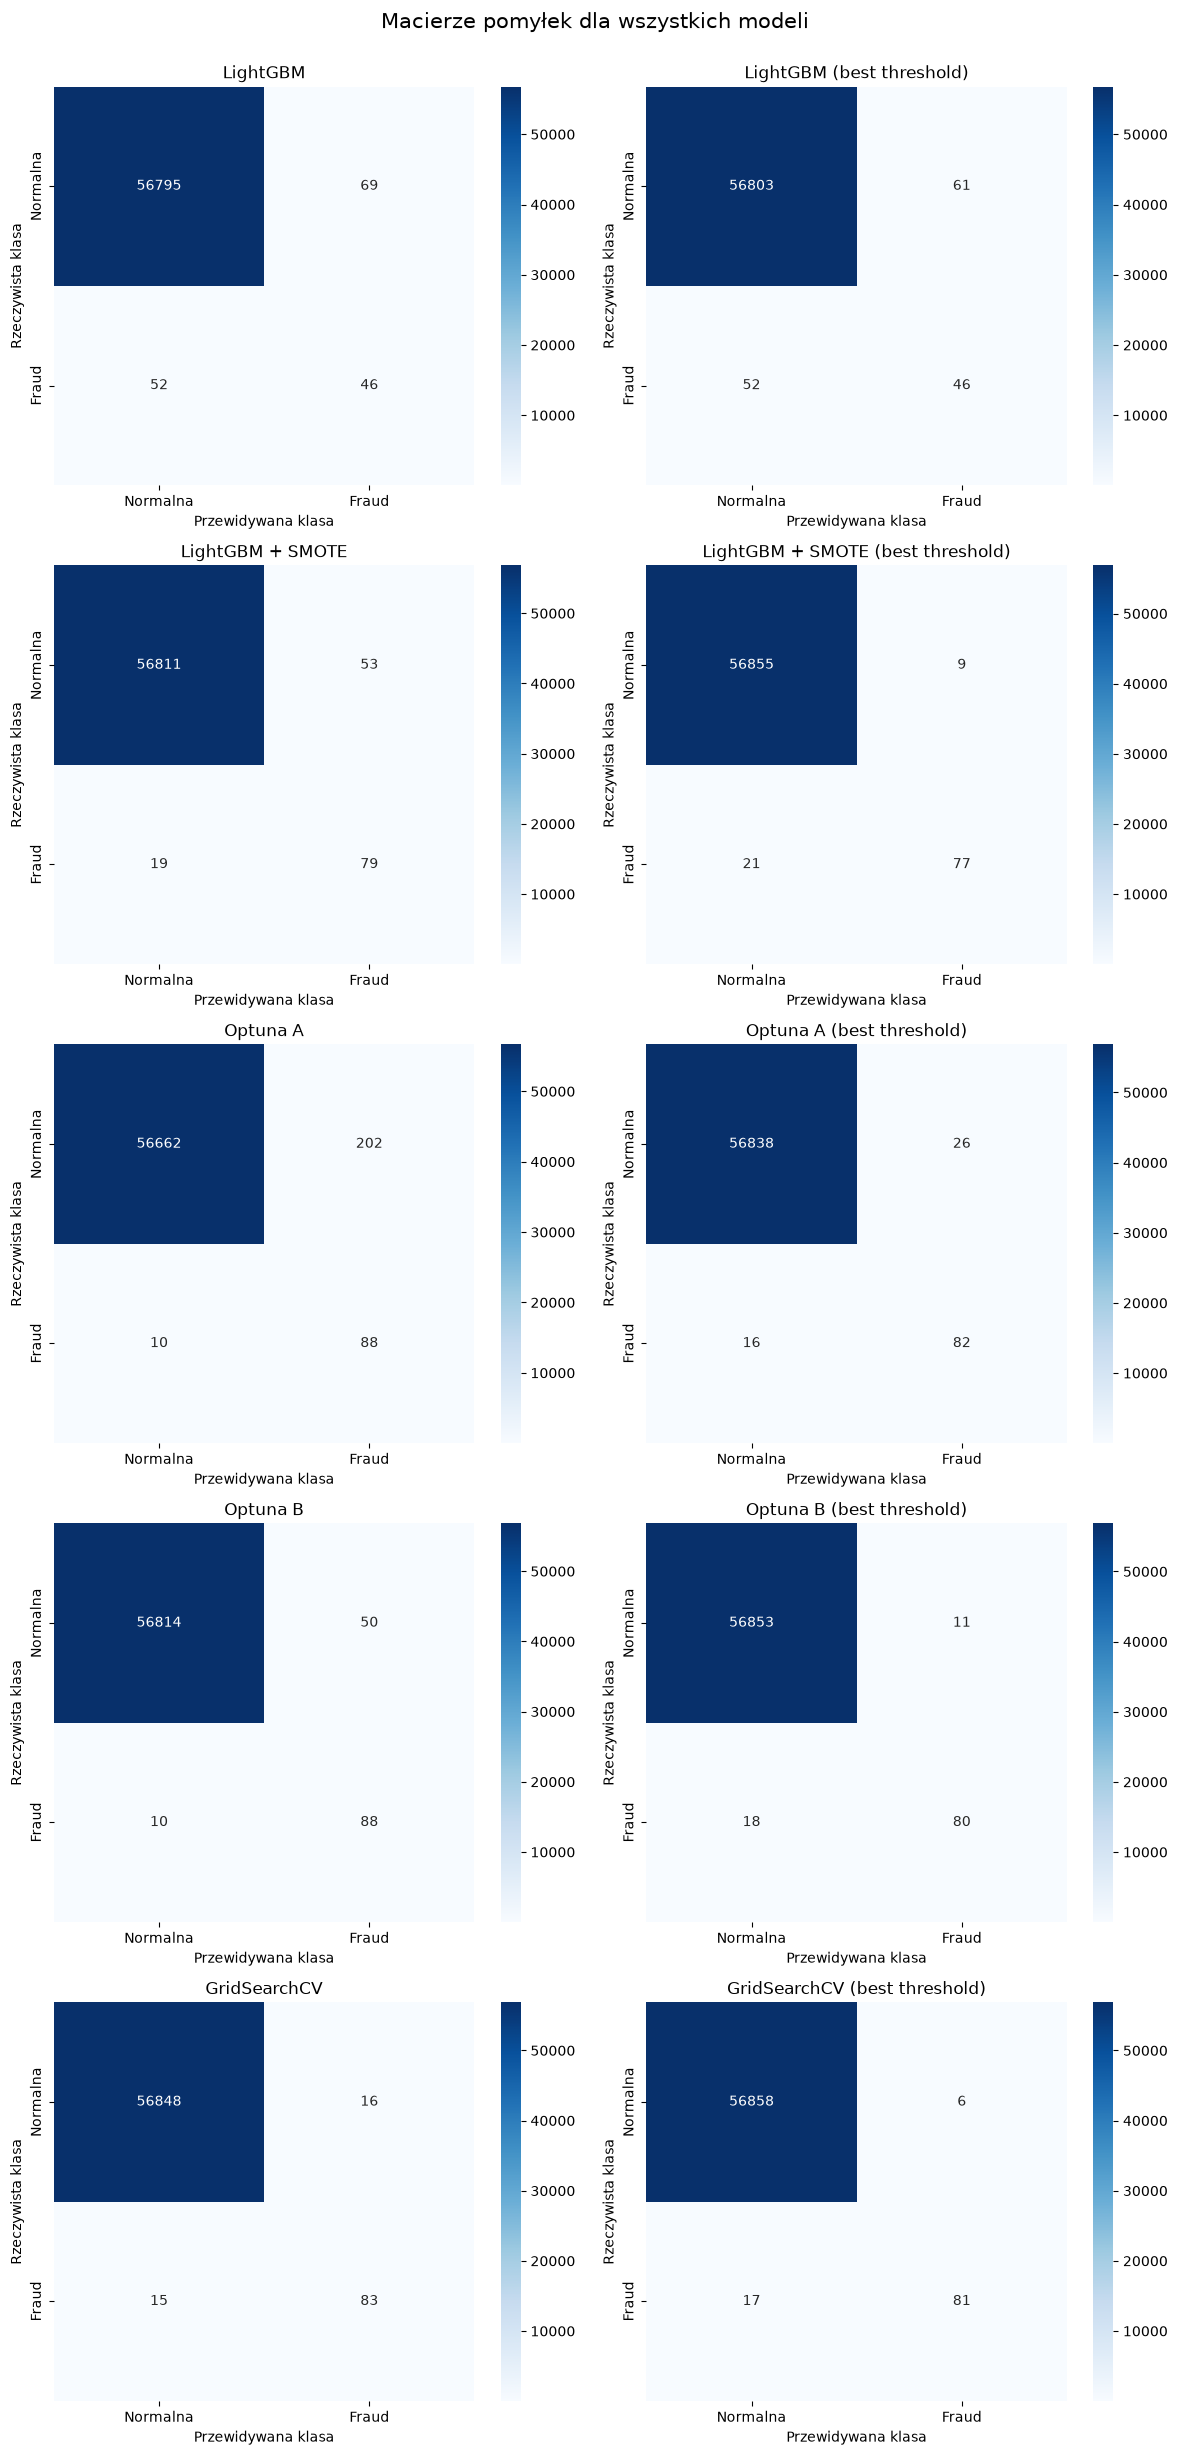

In [37]:
cm_all_models = {
    'LightGBM': confusion_matrix(y_test, model_lgbm.predict(X_test)),
    'LightGBM (best threshold)': confusion_matrix(y_test, y_pred_best_threshold_all_models['LightGBM']),
    'LightGBM + SMOTE': confusion_matrix(y_test, model_lgbm_smote.predict(X_test)),
    'LightGBM + SMOTE (best threshold)': confusion_matrix(y_test, y_pred_best_threshold_all_models['LightGBM + SMOTE']),
    'Optuna A': confusion_matrix(y_test, model_lgbm_smote_A.predict(X_test)),
    'Optuna A (best threshold)': confusion_matrix(y_test, y_pred_best_threshold_all_models['Optuna A']),
    'Optuna B': confusion_matrix(y_test, model_lgbm_smote_B.predict(X_test)),
    'Optuna B (best threshold)': confusion_matrix(y_test, y_pred_best_threshold_all_models['Optuna B']),
    'GridSearchCV': confusion_matrix(y_test, grid_search.predict(X_test)),
    'GridSearchCV (best threshold)': confusion_matrix(y_test, y_pred_best_threshold_all_models['GridSearchCV'])
}
cm_all_models
fig, ax = plt.subplots(5, 2, figsize=(12, 25))
fig.suptitle('Macierze pomyłek dla wszystkich modeli\n\n', fontsize=15)

for idx, (key, cm) in enumerate(cm_all_models.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[math.floor(idx/2), idx%2])
    ax[math.floor(idx/2), idx%2].set_title(key)
    ax[math.floor(idx/2), idx%2].set_xlabel('Przewidywana klasa')
    ax[math.floor(idx/2), idx%2].set_ylabel('Rzeczywista klasa')
    ax[math.floor(idx/2), idx%2].set_xticklabels(['Normalna', 'Fraud'])
    ax[math.floor(idx/2), idx%2].set_yticklabels(['Normalna', 'Fraud'])

plt.tight_layout()
plt.show()

# Precision-Recall wraz z zaznaczonym najlepszym thresholdem dla każdego modelu. Modele poradziły sobie najlepiej w następującej kolejności: GridSearchCV > Optuna B > LightGBM + SMOTE > Optuna A > LightGBM. Najgorszym modelem dla niezbalansowanych danych jest LightGBM. Optuna A dała dość znacznie słabsze wyniki niż Optuna B, ponieważ accuracy_score nie jest najlepszym wyborem dla niezbalansowanych danych, a z tej metryki korzystała Optuna A. Lepszym wyborem może być metryka average_precision_score, która lepiej sprawdza się dla niezbalansowanych danych.

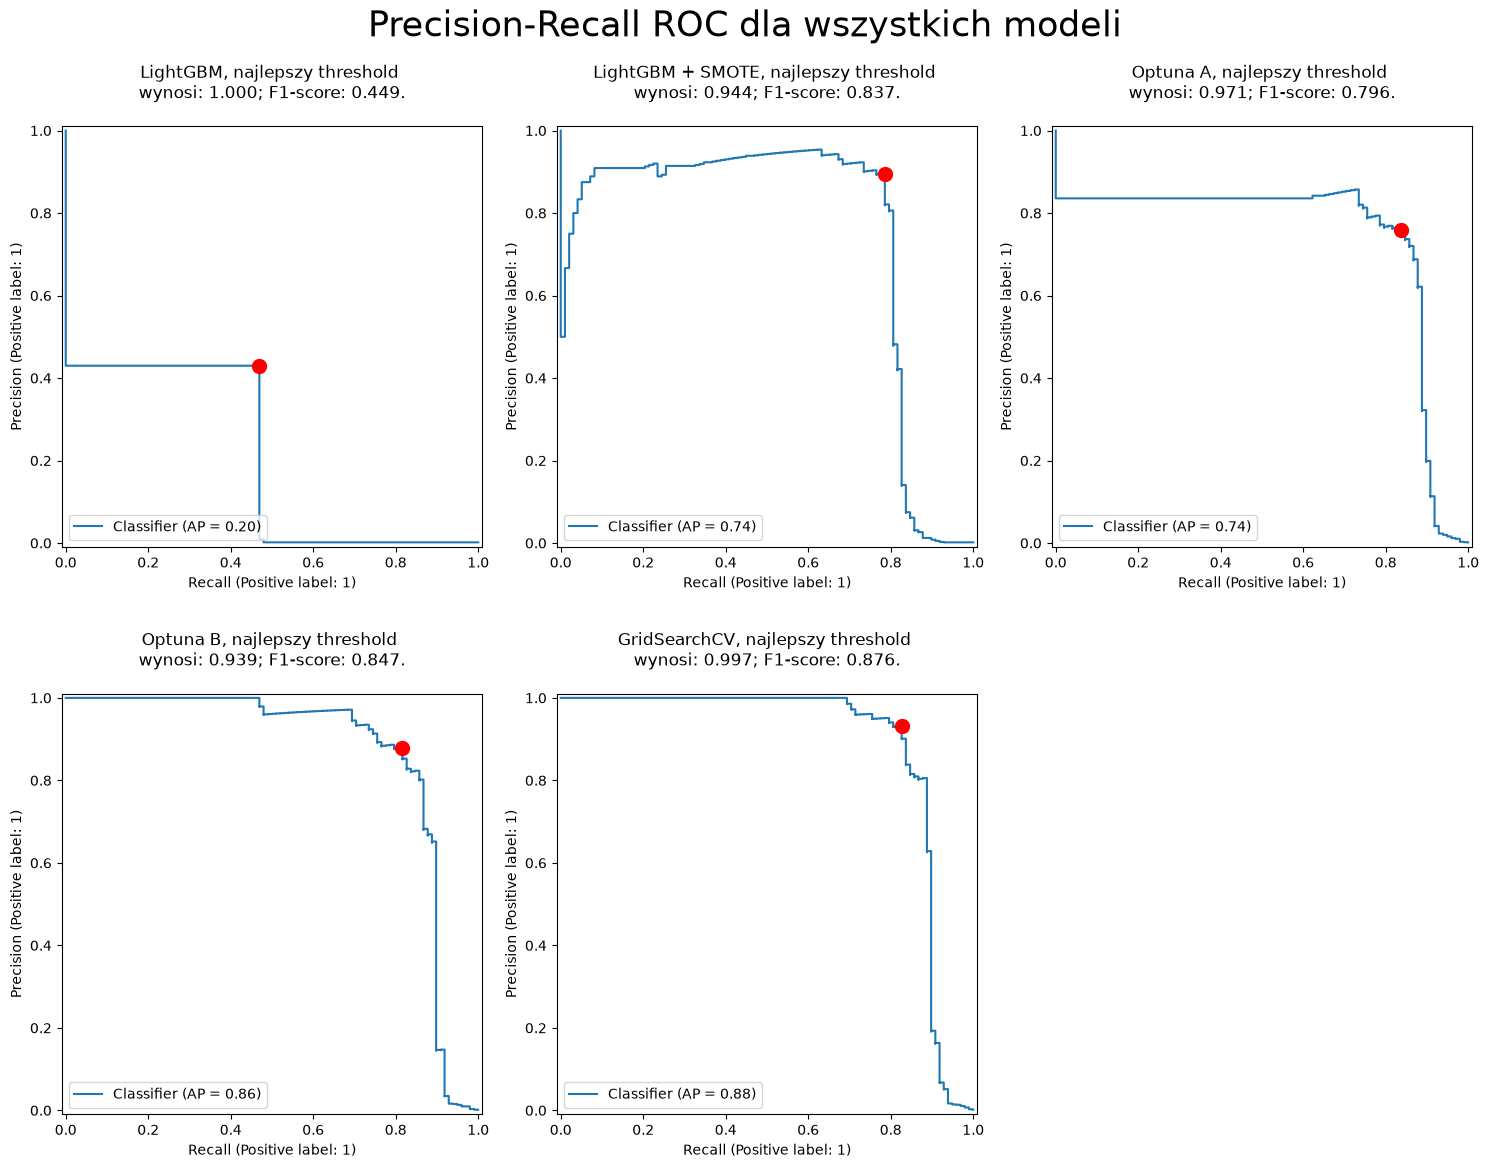

In [38]:
# https://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html
fig, ax = plt.subplots(2, 3, figsize=(15, 12))
fig.suptitle('Precision-Recall ROC dla wszystkich modeli', fontsize=25)

for idx, key in enumerate(results_threshold_best.keys()):
    PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba_all_models[key], ax=ax[math.floor(idx/3), idx%3])
    ax[math.floor(idx/3), idx%3].scatter(results_threshold_best[key]['recall'], results_threshold_best[key]['precision'], color='red', s=100, zorder=5)
    ax[math.floor(idx/3), idx%3].set_title(f'{key}, najlepszy threshold \nwynosi: {results_threshold_best[key]['threshold']:.3f}; F1-score: {results_threshold_best[key]['fscore']:.3f}.\n')

ax[1, 2].remove()
plt.tight_layout()
plt.show()